In [1]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/processed/final_zomato.csv")

df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city),votes_norm,online_order_num,book_table_num,success_score
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari,0.047415,1,1,2.264225
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari,0.048149,1,0,2.164445
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari,0.056164,1,0,2.016849
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari,0.005384,0,0,1.851615
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari,0.010156,0,0,1.903047


In [3]:
location_df = (
    df.groupby("location")
    .agg({
        "rate":"mean",
        "votes":"mean",
        "approx_cost(for two people)":"mean"
    })
    .reset_index()
)

location_df.head()

,location,rate,votes,approx_cost(for two people)
0,BTM,3.556950,96.160935,378.982118
1,Banashankari,3.625991,132.527211,380.884354
2,Banaswadi,3.475524,51.170732,378.048780
3,Bannerghatta Road,3.476000,109.928118,423.340381
4,Basavanagudi,3.675141,157.672986,339.620853


In [4]:
location_df.shape

(93, 4)

In [5]:
features = location_df[
    [
        "rate",
        "votes",
        "approx_cost(for two people)"
    ]
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    features
)

In [7]:
location_df.isnull().sum()

location                       0
rate                           1
votes                          0
approx_cost(for two people)    0
dtype: int64

In [8]:
location_df = location_df.dropna()

In [9]:
location_df = (
    df.groupby("location")
    .agg({
        "rate":"mean",
        "votes":"mean",
        "approx_cost(for two people)":"mean"
    })
    .reset_index()
)

location_df = location_df.dropna()

location_df.head()

,location,rate,votes,approx_cost(for two people)
0,BTM,3.556950,96.160935,378.982118
1,Banashankari,3.625991,132.527211,380.884354
2,Banaswadi,3.475524,51.170732,378.048780
3,Bannerghatta Road,3.476000,109.928118,423.340381
4,Basavanagudi,3.675141,157.672986,339.620853


In [10]:
location_df.isnull().sum()

location                       0
rate                           0
votes                          0
approx_cost(for two people)    0
dtype: int64

In [11]:
features = location_df[
    [
        "rate",
        "votes",
        "approx_cost(for two people)"
    ]
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [12]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(
        scaled_features
    )

    wcss.append(
        kmeans.inertia_
    )

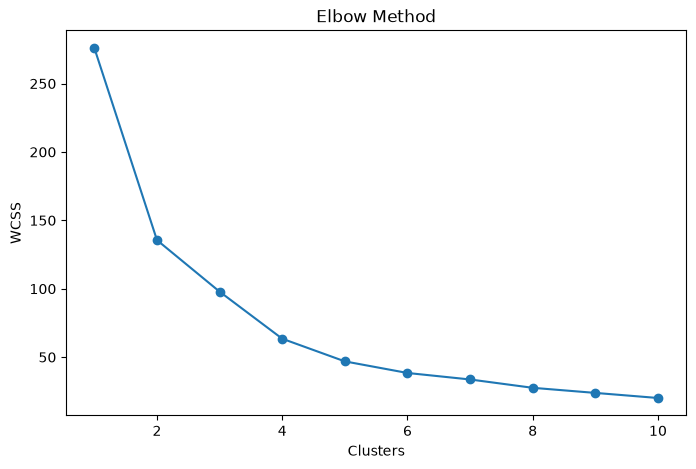

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")

plt.show()

In [14]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

location_df["cluster"] = (
    kmeans.fit_predict(
        scaled_features
    )
)

In [15]:
location_df.sort_values(
    "cluster"
)

,location,rate,votes,approx_cost(for two people),cluster
1,Banashankari,3.625991,132.527211,380.884354,0
4,Basavanagudi,3.675141,157.672986,339.620853,0
5,Basaveshwara Nagar,3.596923,67.514563,397.572816,0
8,Brigade Road,3.675926,296.160305,594.122137,0
15,Cunningham Road,3.736170,284.816327,722.448980,0
...,...,...,...,...,...
82,Thippasandra,3.540816,63.125000,340.138889,3
88,West Bangalore,3.400000,143.250000,362.500000,3
85,"Varthur Main Road, Whitefield",3.530000,35.955556,355.555556,3
90,Wilson Garden,3.453125,22.380000,368.000000,3


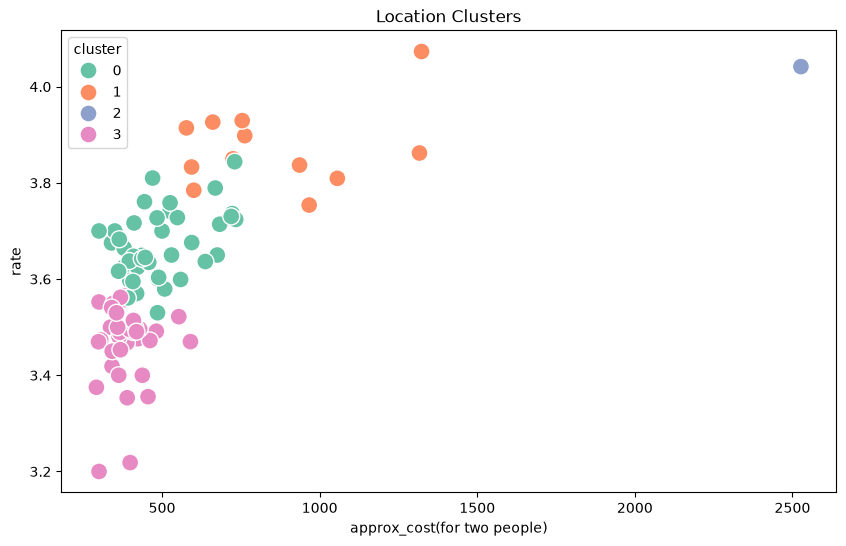

In [16]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=location_df,
    x="approx_cost(for two people)",
    y="rate",
    hue="cluster",
    palette="Set2",
    s=150
)

plt.title(
    "Location Clusters"
)

plt.show()

In [17]:
location_df.groupby(
    "cluster"
).agg({
    "rate":"mean",
    "votes":"mean",
    "approx_cost(for two people)":"mean"
})

,rate,votes,approx_cost(for two people)
cluster,,,
0,3.669377,144.404664,492.108086
1,3.872604,491.562492,856.058534
2,4.041667,233.000000,2526.923077
3,3.465374,57.901584,387.194604


In [18]:
location_df[
    ["location","cluster"]
].sort_values("cluster")

,location,cluster
1,Banashankari,0
4,Basavanagudi,0
5,Basaveshwara Nagar,0
8,Brigade Road,0
15,Cunningham Road,0
...,...,...
82,Thippasandra,3
88,West Bangalore,3
85,"Varthur Main Road, Whitefield",3
90,Wilson Garden,3
